# Waterfall plot + spectral index — CHIME/FRB Baseband Catalog 1

Based on the official example (`Example_make_waterfall.py`) for beamformed files from the
CHIME/FRB Baseband Catalog 1 (CHIME/FRB Coll. et al. 2023). This notebook follows that
example's logic step by step, then adds a spectral index fit at the end.

Note (from the original example): this is a simplified version of the pipeline used to
build the catalog — results will differ slightly from the paper's own numbers.

Set the file path in the next cell before running.

In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
FILENAME = '/fred/oz002/thsu/beamformed_files/beamformed_files/FRB20190102A_24510924_beamformed.h5'  # <-- set your file path

f = h5py.File(FILENAME, 'r')

## Load power

Two options, matching the original example:

- **Option 1 (default, `use_baseband = False`):** use the power array already coherently
  dedispersed and stored in the file (`tiedbeam_power`) — fast, and what most people want.
- **Option 2 (`use_baseband = True`):** start from the raw complex voltages
  (`tiedbeam_baseband`) and do the coherent (intra-channel) dedispersion yourself via an FFT
  transfer function. Slower, but useful if you want to dedisperse to a different DM than the
  one baked into `tiedbeam_power`.

In [15]:
use_baseband = False

#********** Option 1: Use power already coherently dedispersed
if not use_baseband:
    print("Using the power array stored in the file")
    power = f['tiedbeam_power'][:]
    print(f"  DM used to remove signal smearing: {f['tiedbeam_power'].attrs['DM_coherent']:.2f}")

#********** Option 2: Use baseband data with coherent dedispersion to get power
if use_baseband:
    print("Using baseband data")
    from scipy.fft import fft, fftfreq, ifft

    DM = f['tiedbeam_power'].attrs['DM_coherent']  # Same DM used in the paper
    baseband = f['tiedbeam_baseband'][:]  # Load baseband data

    # Apply coherent dedispersion
    print("  Running coherent dedispersion")
    freq_fft = fftfreq(
        baseband.shape[-1],
        d=f.attrs["delta_time"] * 1e6,
    )
    f0 = f['index_map']["freq"]["centre"][:, np.newaxis]
    K_DM = 1 / 0.241e-3
    H = np.exp(2j * np.pi * 1e6 * K_DM * DM * freq_fft**2 / (freq_fft + f0) / f0 ** 2)  # Intrachannel dispersion transfer function
    dedispersed_array = ifft(
        fft(
            np.nan_to_num(
                baseband
            )
        )
        * H[:, np.newaxis]
    )  # Dedispersion
    dedispersed_array[np.isnan(baseband)] = np.nan  # Mask NaN values in original data
    power = np.abs(dedispersed_array) ** 2

Using the power array stored in the file
  DM used to remove signal smearing: 699.20


## Total intensity (Stokes I)

Average the two linear polarizations.

Total intensity
  It has shape (168, 2, 66728) - (frequency channels, linear polarizations, time bins).


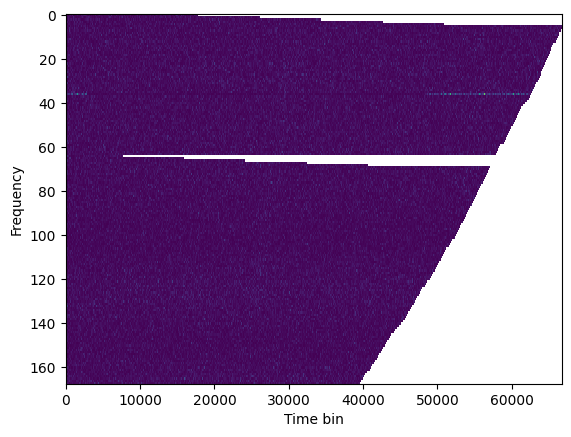

In [16]:
print("Total intensity")
print(f"  It has shape {power.shape} - (frequency channels, linear polarizations, time bins).")
total_intensity = np.mean(power, axis=1)

plt.imshow(
    total_intensity,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin')
plt.ylabel('Frequency')
plt.show()

## Fill missing channels with NaN

Only a subset of the 1024 channels may be present in this file; re-expand to the full band
so channel index lines up with physical frequency, masking the rest with NaN.

Fill missing channels


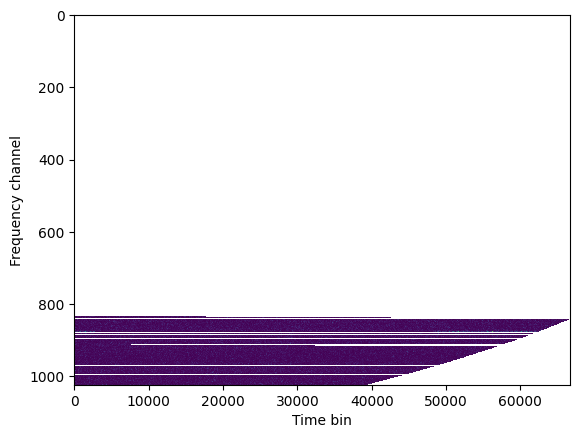

In [17]:
print("Fill missing channels")
freq_id = f['index_map']['freq']['id']
waterfall = np.zeros([1024, total_intensity.shape[1]]) + np.nan
waterfall[freq_id] = total_intensity

plt.imshow(
    waterfall,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin')
plt.ylabel('Frequency channel')
plt.show()

## Convert to S/N

Rough per-channel normalization (subtract channel mean, divide by channel std) — not a
proper off-pulse-only noise estimate yet, just a quick-look conversion.

S/N


/tmp/ipykernel_866845/3835738547.py:2: RuntimeWarning: Mean of empty slice
  sn = waterfall - np.nanmean(waterfall, axis=1)[:, np.newaxis]


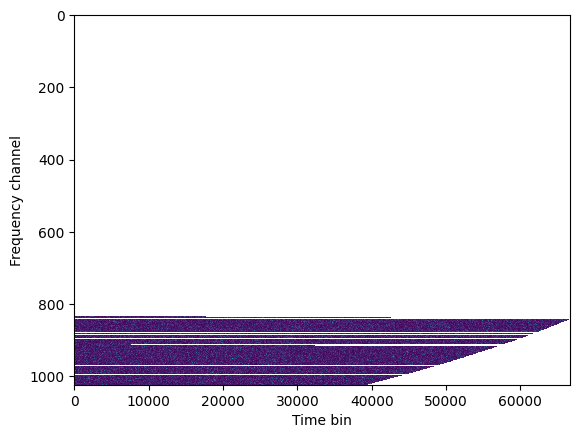

In [18]:
print("S/N")
sn = waterfall - np.nanmean(waterfall, axis=1)[:, np.newaxis]
sn /= np.nanstd(sn, axis=1)[:, np.newaxis]

plt.imshow(
    sn,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin')
plt.ylabel('Frequency channel')
plt.show()

## Downsample in time

Sum (not average) the non-NaN bins in each channel and rescale by `sqrt(down_factor)` to
keep it in S/N units. `nanmean` is used instead of `nansum` so NaNs are preserved rather than
treated as zero.

Downsampled


/tmp/ipykernel_866845/2589804841.py:5: RuntimeWarning: Mean of empty slice
  np.nanmean(


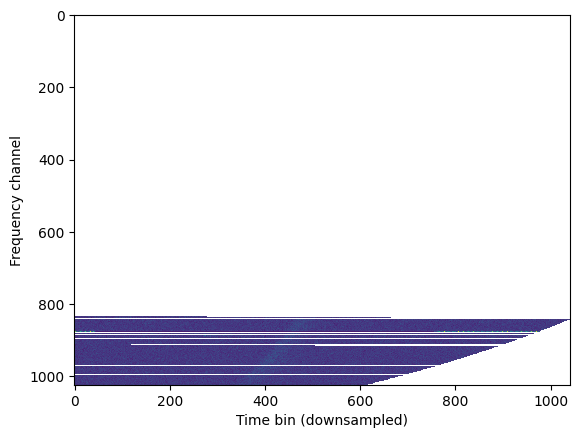

In [19]:
print("Downsampled")
down_factor = 64
sn = sn[..., :sn.shape[-1]//down_factor*down_factor]
sn_down = (
    np.nanmean(
        sn.reshape(sn.shape[0], sn.shape[1] // down_factor, down_factor),
        axis=-1
    ) * np.sqrt(down_factor)
)
plt.imshow(
    sn_down,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin (downsampled)')
plt.ylabel('Frequency channel')
plt.show()
# The burst should start to become visible here, though it looks poorly dedispersed --
# that's expected, since each channel currently starts recording at an arbitrary time.

## RFI excision

Iteratively flag (as NaN) channels whose standard deviation or mean is a large outlier
relative to the rest of the band. Runs for up to 10 iterations.

/tmp/ipykernel_866845/2663990510.py:13: RuntimeWarning: Mean of empty slice
  spect = np.nanmean(sn_down, axis=1)


RFI excision


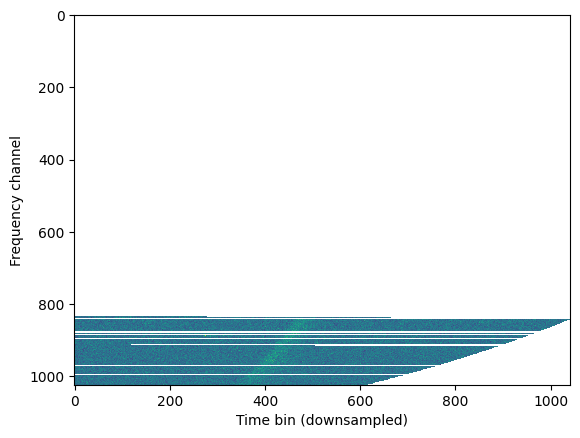

In [20]:
print("RFI excision")
sn_threshold = 5
idx_rfi_out = np.zeros(sn_down.shape[0], dtype=bool)
for jj in range(10):
    # Remove channels with standard deviations over 5 times larger than the average
    spect = np.nanstd(sn_down, axis=1)
    spect -= np.nanmedian(spect)
    spect /= np.nanstd(spect)
    idx_rfi = spect > sn_threshold
    sn_down[idx_rfi] = np.nan
    idx_rfi_out = idx_rfi_out | idx_rfi
    # Remove channels with values over 5 times larger than the average
    spect = np.nanmean(sn_down, axis=1)
    spect -= np.nanmedian(spect)
    spect /= np.nanstd(spect)
    idx_rfi = spect > sn_threshold
    sn_down[idx_rfi] = np.nan
    idx_rfi_out = idx_rfi_out | idx_rfi

plt.imshow(
    sn_down,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin (downsampled)')
plt.ylabel('Frequency channel')
plt.show()

## Incoherent dedispersion

Each channel's recording starts at a different absolute time (`time0/ctime`); shift channels
relative to each other using the DM to align the burst across the band, referenced to the
top of the band.

De-dispersed


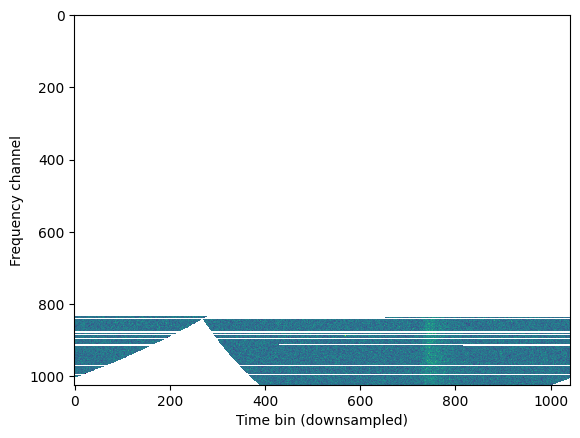

In [21]:
print("De-dispersed")
t0 = f['time0']['ctime'] - f['time0']['ctime'].min()  # seconds
freq = f['index_map']['freq']['centre']
freq_ref = freq.max()
dm = f['tiedbeam_power'].attrs['DM_coherent']  # Same DM used for coherent dedispersion
dt = f.attrs['delta_time'] * down_factor  # seconds, after downsampling

def incoherent_dedisp(array_in, dm, time0, freq, freq_id, dt=2.56e-6, freq_ref=400):
    array_out = np.zeros_like(array_in) + np.nan
    for t, fr, f_id in zip(time0, freq, freq_id):
        dm_delay = dm / 2.41e-4 * (fr**-2 - freq_ref**-2)
        bins_shift = np.round((t - dm_delay) / dt).astype(int)
        array_out[f_id] = np.roll(array_in[f_id], bins_shift, axis=-1)
    return array_out

sn_dedisp = incoherent_dedisp(sn_down, dm, t0, freq, freq_id, dt=dt, freq_ref=freq_ref)

plt.imshow(
    sn_dedisp,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin (downsampled)')
plt.ylabel('Frequency channel')
plt.show()

## Final cut around the burst

Find the peak of the frequency-summed profile and window ±40 ms (default `window_ms = 80`)
around it, now in physical units (ms, MHz).

Final cut


/tmp/ipykernel_866845/2028032468.py:81: RuntimeWarning: Mean of empty slice
  spectrum_snr = np.nanmean(wfall_cut[:, box_start:box_end], axis=1)


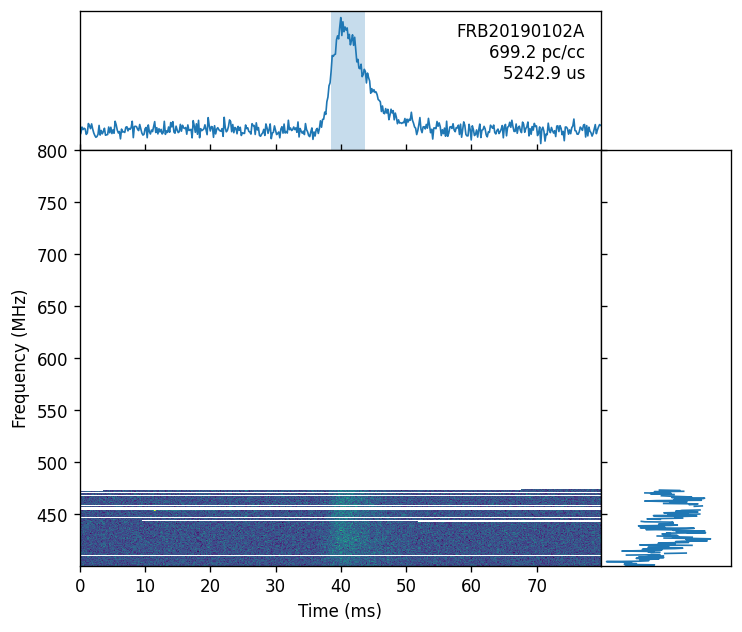

  Boxcar width: 5242.9 us (32 bins), peak S/N = 39.8


In [22]:
print("Final cut")
window_ms = 80  # ms
window_bins = int(window_ms / dt / 1000)
profile = np.nansum(sn_dedisp, axis=0) / np.sqrt(np.sum(~np.isnan(np.nansum(sn_dedisp, axis=1))))
bin_start = np.nanargmax(profile) - window_bins // 2
bin_end = np.nanargmax(profile) + window_bins // 2

# `freq` (and freq_id) are only defined for the channels actually present in the file, which
# is a *subset* of the 1024-channel band -- e.g. missing edge channels or ones flagged as RFI.
# Fit the (uniform, linear) channel -> frequency relation from those present channels and
# extrapolate it across all 1024 channels, so the y-axis reflects the true full band rather
# than being squashed to whatever channels happen to survive.
_slope, _intercept = np.polyfit(freq_id, freq, 1)
freq_full = _slope * np.arange(1024) + _intercept   # MHz, defined for every channel row
freq_lim = (freq_full.min(), freq_full.max())

wfall_cut = sn_dedisp[:, bin_start:bin_end]           # (1024, n_bins) burst window, S/N units
profile_cut = profile[bin_start:bin_end]              # frequency-summed time series, same window
time_ms = np.arange(wfall_cut.shape[1]) * dt * 1000    # ms, relative to window start


def boxcar_search(profile, max_width_frac=0.25):
    """Slide dyadic boxcar widths over `profile`, return the (width, start_bin, S/N)
    of the boxcar that maximizes S/N -- i.e. an automatic on-burst duration/position."""
    n = len(profile)
    max_width = max(1, int(n * max_width_frac))
    widths = [2 ** i for i in range(0, int(np.log2(max_width)) + 1)]
    best_snr, best_width, best_start = -np.inf, 1, int(np.nanargmax(profile))
    for w in widths:
        kernel = np.ones(w) / np.sqrt(w)
        conv = np.convolve(np.nan_to_num(profile), kernel, mode='valid')
        idx = int(np.nanargmax(conv))
        if conv[idx] > best_snr:
            best_snr, best_width, best_start = conv[idx], w, idx
    return best_width, best_start, best_snr


# On-burst window (the "boxcar"): used both to shade the time series and to restrict
# the spectrum on the right to on-burst bins only.
box_width, box_start, box_snr = boxcar_search(profile_cut)
box_end = min(box_start + box_width, len(time_ms) - 1)
box_time_start = time_ms[box_start]
box_time_end = time_ms[box_end]
box_width_us = box_width * dt * 1e6  # microseconds

frb_name = Path(FILENAME).stem.split("_")[0]

# ---- 3-panel figure: time series (top) + waterfall (main) + on-burst spectrum (right) ----
# wspace/hspace = 0 so the three panels sit flush against each other as one rectangle,
# matching the reference layout.
fig = plt.figure(figsize=(7, 6), dpi=120)
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 3), wspace=0.0, hspace=0.0)
ax_time = fig.add_subplot(gs[0, 0])
ax_wfall = fig.add_subplot(gs[1, 0], sharex=ax_time)
ax_spec = fig.add_subplot(gs[1, 1], sharey=ax_wfall)

ax_wfall.imshow(
    wfall_cut,
    interpolation='none',
    aspect='auto',
    origin='upper',
    extent=[time_ms[0], time_ms[-1], freq_lim[0], freq_lim[1]],
)
ax_wfall.set_xlabel('Time (ms)')
ax_wfall.set_ylabel('Frequency (MHz)')

# Time series, with the boxcar (on-burst window) shaded
ax_time.plot(time_ms, profile_cut, lw=1, color='tab:blue')
ax_time.axvspan(box_time_start, box_time_end, color='tab:blue', alpha=0.25, lw=0)
ax_time.set_xlim(time_ms[0], time_ms[-1])
plt.setp(ax_time.get_xticklabels(), visible=False)
ax_time.tick_params(axis='x', direction='in')
ax_time.set_yticks([])
ax_time.text(
    0.97, 0.92,
    f"{frb_name}\n{dm:.1f} pc/cc\n{box_width_us:.1f} us",
    transform=ax_time.transAxes, ha='right', va='top', fontsize=10
)

# On-burst spectrum: average S/N over the boxcar time bins only, per frequency channel
spectrum_snr = np.nanmean(wfall_cut[:, box_start:box_end], axis=1)
ax_spec.plot(spectrum_snr, freq_full, lw=1, color='tab:blue')
plt.setp(ax_spec.get_yticklabels(), visible=False)
ax_spec.tick_params(axis='y', direction='in')
ax_spec.set_xticks([])

plt.show()
print(f"  Boxcar width: {box_width_us:.1f} us ({box_width} bins), peak S/N = {box_snr:.1f}")

## Fluence

Repeat the fill/RFI-mask/dedisperse steps on the *power* array (not just S/N), select an
off-pulse region for background subtraction, normalize each channel to physical units
(Jy) using `index_map/amplitude_norm`, and integrate to get the burst fluence in Jy·ms.

In [23]:
print("Fluence")

# Fill missing channels with NaN
power_clean = np.zeros([1024, 2, total_intensity.shape[1]]) + np.nan
power_clean[freq_id] = power
# Mask RFI
power_clean[np.isnan(np.nanmean(sn_down, axis=1))] = np.nan
# Dedisperse (incoherently)
power_clean = incoherent_dedisp(power_clean, dm, t0, freq, freq_id, dt=f.attrs['delta_time'], freq_ref=freq_ref)
# Cut around the burst
power_clean = power_clean[..., bin_start*down_factor: bin_end*down_factor]

# Off-pulse region: remove any bins in the profile with |RMS| > 3, iteratively
off_pulse = profile.copy() - np.nanmedian(profile)
while np.nanmax(np.abs(off_pulse)) > 3:
    off_pulse[np.abs(off_pulse) > 3] = np.nan
    off_pulse -= np.nanmean(off_pulse)
    off_pulse /= np.nanstd(off_pulse)
off_pulse = off_pulse[bin_start:bin_end]
idx_off = np.repeat(~np.isnan(off_pulse), down_factor)
bg = power_clean[..., idx_off]

# Subtract off-pulse spectrum
spect_off_pulse = np.nanmean(bg, axis=-1)
spectrum = (power_clean - spect_off_pulse[..., np.newaxis])

# Normalization to transform each channel of the spectrum to Jy
normalization_factor = np.zeros([1024, 2]) + np.nan
normalization_factor[freq_id] = f['index_map']['amplitude_norm']
normalization_factor[np.isnan(np.nanmean(sn_down, axis=1))] = np.nan

# Fluence: rectangular integral of the normalized profile, summed over polarizations
fluence = np.nansum(
    np.nanmean(spectrum, axis=0) /
    np.nanmean(normalization_factor, axis=0)[:, np.newaxis]
) * f.attrs['delta_time'] * 1e3  # ms

print(f"  Fluence = {fluence:.1f} Jy ms")

Fluence


/tmp/ipykernel_866845/4033270146.py:7: RuntimeWarning: Mean of empty slice
  power_clean[np.isnan(np.nanmean(sn_down, axis=1))] = np.nan
/tmp/ipykernel_866845/4033270146.py:24: RuntimeWarning: Mean of empty slice
  spect_off_pulse = np.nanmean(bg, axis=-1)
/tmp/ipykernel_866845/4033270146.py:30: RuntimeWarning: Mean of empty slice
  normalization_factor[np.isnan(np.nanmean(sn_down, axis=1))] = np.nan


  Fluence = 88.3 Jy ms


## Spectral index

Extends the example above: instead of collapsing `spectrum` over frequency (as the fluence
calculation does), keep the per-channel resolution to get an on-burst flux density per
channel, normalized to Jy the same way as the fluence step. Then fit
`log(S_ν) = α·log(ν) + const` in log-log space across the surviving (non-RFI, non-NaN)
channels.

Caveats:
- This is a single dedispersed-burst-window spectrum — no time-resolved (sub-burst)
  spectral index is computed here, just one number for the whole window selected above.
- Sub-band structure (scintillation, band-limited emission) can bias a single power-law fit;
  look at the printed per-channel spectrum if the fit looks poor.
- Channels flagged as RFI or lying outside `freq_id` are NaN and automatically excluded.

In [24]:
print(spectrum.shape, normalization_factor.shape)

(1024, 2, 31232) (1024, 2)


Spectral index


/tmp/ipykernel_866845/3159895480.py:5: RuntimeWarning: Mean of empty slice
  np.nanmean(np.nanmean(spectrum, axis=1), axis=1) /
/tmp/ipykernel_866845/3159895480.py:6: RuntimeWarning: Mean of empty slice
  np.nanmean(normalization_factor, axis=1)


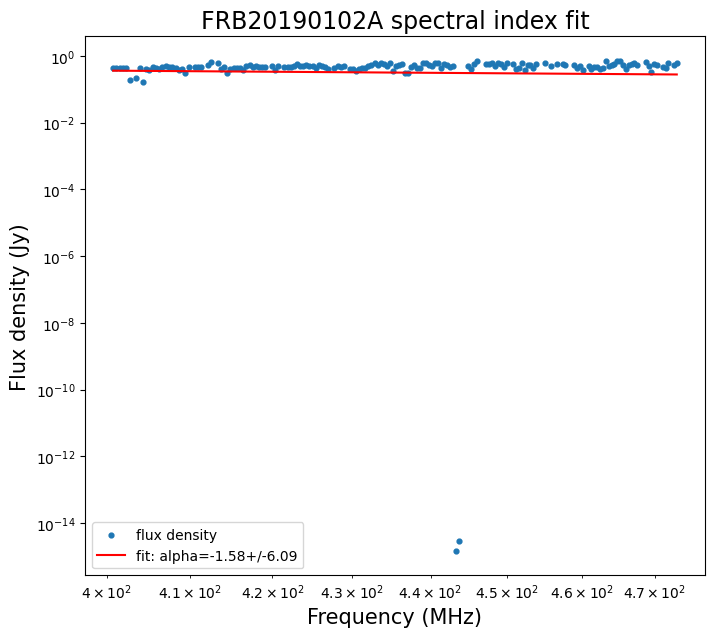

  Spectral index: alpha = -1.581 +/- 6.087  (S_nu ~ nu^alpha)


In [25]:
print("Spectral index")
# Per-channel flux density in Jy: average over polarizations and over the burst window,
# normalized the same way as the fluence calculation.
flux_channel = (
    np.nanmean(np.nanmean(spectrum, axis=1), axis=1) /
    np.nanmean(normalization_factor, axis=1)
)

mask = np.isfinite(flux_channel) & (flux_channel > 0) & np.isfinite(freq_full)

log_f = np.log10(freq_full[mask])
log_s = np.log10(flux_channel[mask])

coeffs, cov = np.polyfit(log_f, log_s, 1, cov=True)
alpha, const = coeffs
alpha_err = np.sqrt(cov[0, 0])

fig, ax = plt.subplots(figsize=(8, 7), dpi = 100)
ax.scatter(freq_full[mask], flux_channel[mask], s=12, label='flux density')
fit_line = 10 ** (alpha * log_f + const)
ax.plot(freq_full[mask], fit_line, 'r-', label=f'fit: alpha={alpha:.2f}+/-{alpha_err:.2f}')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency (MHz)', fontsize=15)
ax.set_ylabel('Flux density (Jy)', fontsize=15)
ax.legend()
ax.set_title(f"{frb_name} spectral index fit"   , fontsize=17)
plt.show()

print(f"  Spectral index: alpha = {alpha:.3f} +/- {alpha_err:.3f}  (S_nu ~ nu^alpha)")

## Final cut, with boxcar-derived spectral index

Same time series + waterfall as the "Final cut" cell above, but the right-hand panel now
shows the flux-calibrated (Jy) spectrum computed only from the boxcar (on-burst) time range,
with the power-law spectral index fit overlaid, instead of a plain S/N line.

Spectral index (boxcar only)
  Spectral index (boxcar only): alpha = 2.594 +/- 0.321  (S_nu ~ nu^alpha)


/tmp/ipykernel_866845/71601794.py:13: RuntimeWarning: Mean of empty slice
  np.nanmean(np.nanmean(spectrum[..., box_start_fullres:box_end_fullres], axis=1), axis=1) /
/tmp/ipykernel_866845/71601794.py:14: RuntimeWarning: Mean of empty slice
  np.nanmean(normalization_factor, axis=1)


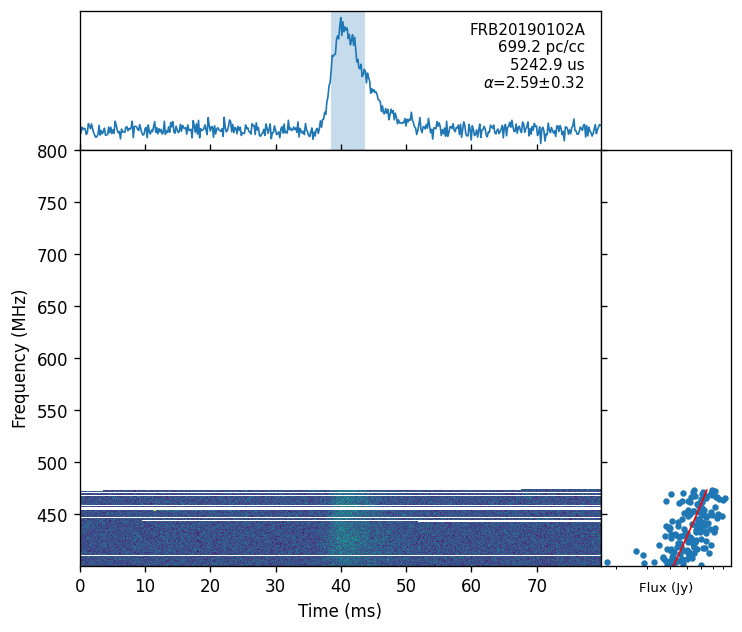

In [26]:
print("Spectral index (boxcar only)")

# `box_start`/`box_end` (from the "Final cut" cell) are bin indices on the DOWNSAMPLED grid
# (profile_cut / wfall_cut, cadence `dt`). `spectrum` (from the Fluence cell) is on the native,
# full time-resolution grid over the same [bin_start, bin_end] window. Scale by `down_factor`
# to map the boxcar onto `spectrum`'s indexing.
box_start_fullres = box_start * down_factor
box_end_fullres = min(box_end * down_factor, spectrum.shape[-1])

# Per-channel flux density in Jy, averaged over polarizations and ONLY over the boxcar
# (on-burst) time range -- same normalization as the fluence/spectral-index cells above.
flux_channel_box = (
    np.nanmean(np.nanmean(spectrum[..., box_start_fullres:box_end_fullres], axis=1), axis=1) /
    np.nanmean(normalization_factor, axis=1)
)

# Keeps only channels that are not RFI-masked/NaN and have a physically meaningful
# positive flux (needed since we're about to take a log).
mask_box = np.isfinite(flux_channel_box) & (flux_channel_box > 0)

log_f_box = np.log10(freq_full[mask_box])
log_s_box = np.log10(flux_channel_box[mask_box])

coeffs_box, cov_box = np.polyfit(log_f_box, log_s_box, 1, cov=True)
alpha_box, const_box = coeffs_box
alpha_box_err = np.sqrt(cov_box[0, 0])
fit_line_box = 10 ** (alpha_box * log_f_box + const_box)

print(f"  Spectral index (boxcar only): alpha = {alpha_box:.3f} +/- {alpha_box_err:.3f}  (S_nu ~ nu^alpha)")

# ---- Same 3-panel layout as "Final cut", but the right panel is now the boxcar-derived,
# flux-calibrated (Jy) spectrum with the power-law fit overlaid, instead of a plain S/N line ----
from matplotlib.ticker import LogLocator, NullFormatter

fig = plt.figure(figsize=(7, 6), dpi=120)
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 3), wspace=0.0, hspace=0.0)
ax_time = fig.add_subplot(gs[0, 0])
ax_wfall = fig.add_subplot(gs[1, 0], sharex=ax_time)
ax_spec = fig.add_subplot(gs[1, 1], sharey=ax_wfall)

ax_wfall.imshow(
    wfall_cut,
    interpolation='none',
    aspect='auto',
    origin='upper',
    extent=[time_ms[0], time_ms[-1], freq_lim[0], freq_lim[1]],
)
ax_wfall.set_xlabel('Time (ms)')
ax_wfall.set_ylabel('Frequency (MHz)')

ax_time.plot(time_ms, profile_cut, lw=1, color='tab:blue')
ax_time.axvspan(box_time_start, box_time_end, color='tab:blue', alpha=0.25, lw=0)
ax_time.set_xlim(time_ms[0], time_ms[-1])
plt.setp(ax_time.get_xticklabels(), visible=False)
ax_time.tick_params(axis='x', direction='in')
ax_time.set_yticks([])
ax_time.text(
    0.97, 0.92,
    f"{frb_name}\n{dm:.1f} pc/cc\n{box_width_us:.1f} us\n"
    f"$\\alpha$={alpha_box:.2f}$\\pm${alpha_box_err:.2f}",
    transform=ax_time.transAxes, ha='right', va='top', fontsize=9
)

# Boxcar-derived flux density (Jy) per channel, with the power-law fit overlaid
ax_spec.scatter(flux_channel_box[mask_box], freq_full[mask_box], s=8, color='tab:blue')
ax_spec.plot(fit_line_box, freq_full[mask_box], 'r-', lw=1)
ax_spec.set_xscale('log')
ax_spec.xaxis.set_major_locator(LogLocator(base=10, numticks=3))
ax_spec.xaxis.set_minor_formatter(NullFormatter())
plt.setp(ax_spec.get_xticklabels(), fontsize=7, rotation=45)
plt.setp(ax_spec.get_yticklabels(), visible=False)
ax_spec.tick_params(axis='y', direction='in')
ax_spec.set_xlabel('Flux (Jy)', fontsize=8)

plt.show()